Anomalous glacier:   
RGI60-15.11833, GRI60-15.12579 for 2000-2022.



### Elevation change drived by altimeter 


In [83]:
import h5py
import numpy as np
from glob import glob
from shapely.geometry import Point
import rasterio as rio
import geopandas as gpd
from rasterio.mask import mask
import matplotlib.pyplot as plt 
import pandas as pd 


In [84]:
def dif_ele_dem(dem_rio, gla_gpd, path_ele):
    ele_dict = {}
    with h5py.File(path_ele, 'r') as f_read:
      for key in f_read.keys(): ele_dict[key] = f_read[key][:]
    pts = list(zip(ele_dict['lon'], ele_dict['lat']))
    geom_fp = [Point(pt) for pt in pts]
    dict_gpd = {'h': ele_dict['h'], 'geometry':geom_fp}
    ele_gpd = gpd.GeoDataFrame(dict_gpd, crs="EPSG:4326")
    gla_gpd_contain = gla_gpd['geometry'].values[0].contains(ele_gpd['geometry'])
    if gla_gpd_contain.sum() > 0:
      ele_gpd_sel = ele_gpd[gla_gpd_contain]
      pts_x = [pt.xy[0][0] for pt in ele_gpd_sel['geometry'].values]
      pts_y = [pt.xy[1][0] for pt in ele_gpd_sel['geometry'].values]
      rows, cols = rio.transform.rowcol(transform=dem_rio.transform, xs = pts_x, ys = pts_y)
      dif_ele = ele_gpd_sel['h'].values - dem_rio.read(1)[rows, cols]
      dif_ele[abs(dif_ele)>100] = np.nan
      dif_ele_mean = np.nanmean(dif_ele)
    else: dif_ele_mean, ele_gpd_sel = np.nan, np.nan
    return dif_ele_mean, ele_gpd_sel



In [97]:
path_rgi60_setp = 'data/land-cover/rgi60/rgi60_setp.shp'
path_dem = 'data/dem-data/srtm-c/tiles/tile_29_96.tif'
path_result_glacier = 'data/ele-change-result/ele_change_glaciers.pkl'
paths_isat1 = sorted(glob('data/icesat-1/GLAH14-????/tiles/tile_29_96.h5'))
paths_isat2 = sorted(glob('data/icesat-2/ATL06-????/tiles/tile_29_96.h5'))
paths_cryo2 = sorted(glob('data/cryosat-2/eolis-point-????/tiles/tile_29_96.h5')) 
# path_Hugonnet_wgs84 = 'data/ele-change-dset/N29E096_2000-01-01_2010-01-01_dhdt_wgs84.tif'
path_Hugonnet_wgs84 = 'data/ele-change-dset/N29E094_2000-01-01_2020-01-01_dhdt_wgs84.tif'
path_ours = 'data/ele-change-result/ele_change_glaciers.pkl'
paths_isat2


['data/icesat-2/ATL06-2018/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2019/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2020/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2021/tiles/tile_29_96.h5',
 'data/icesat-2/ATL06-2022/tiles/tile_29_96.h5']

In [98]:
rgi60_glaciers = gpd.read_file(path_rgi60_setp)
dem_rio = rio.open(path_dem)
ele_change_hugonnet = rio.open(path_Hugonnet_wgs84 )
ele_change_ours = pd.read_pickle(path_ours) 
result_glaciers = pd.read_pickle(path_result_glacier)


Glacier: RGI60-15.12579


Glacier elevation rate: 0.3956999583581907


Text(0, 0.5, 'Glacier elevation change')

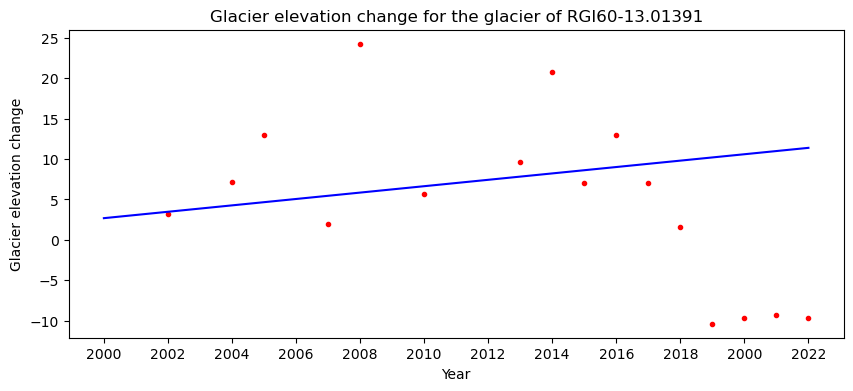

In [88]:
## Our result
fig, ax = plt.subplots(1,1,figsize=(10,4))
# gla_sta_1 = result_glaciers[result_glaciers.rgi_id=='RGI60-15.12579']
gla_sta_1 = result_glaciers[result_glaciers.rgi_id=='RGI60-13.01391']
print('Glacier elevation rate:', gla_sta_1['rate'].values[0])
plt.plot(gla_sta_1['ele_change'].values[0], '.r')
plt.plot(gla_sta_1['ele_change_fitting'].values[0], '-b', label='ele_change_rate')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]);
ax.set_xticklabels(['2000', '2002','2004','2006','2008', \
                    '2010','2012','2014','2016','2018','2000','2022']);
ax.set_title('Glacier elevation change for the glacier of RGI60-13.01391')
ax.set_xlabel('Year')
ax.set_ylabel('Glacier elevation change')


1. compare with the altimetry-derived result

In [89]:
gla_sel_1 = rgi60_glaciers[rgi60_glaciers['RGIId']=='RGI60-13.01391']
gla_sel_1 = gla_sel_1.to_crs(4326)
gla_sel_1

,RGIId,Area,CenLon,CenLat,Zmin,Zmax,Zmed,Slope,Aspect,Lmax,geometry
784,RGI60-13.01391,5.036,94.926392,29.818119,3617,6167,4790,31.1,210,6110,"POLYGON ((94.94330 29.83353, 94.94358 29.83322..."


In [90]:
# dif_ele_means = []
# for path in paths_cryo2:
#   print(path)
#   dif_ele_mean, _ = dif_ele_dem(dem_rio=dem_rio, gla_gpd=gla_sel_1, path_ele=path)
#   dif_ele_means.append(dif_ele_mean)
#   print(dif_ele_mean)


In [91]:
# print(np.nanmean(dif_ele_means))
# np.nanmean(dif_ele_means)/22


In [92]:
# dif_ele_mean, ele_gpd_sel = dif_ele_dem(dem_rio=dem_rio, gla_gpd=gla_sel_1, path_ele=paths_isat2[2])
# fig, ax = plt.subplots(1,1)
# gla_sel_1.plot(ax=ax, facecolor='green', alpha=0.2)
# gla_sel_1.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
# ele_gpd_sel.plot(ax=ax, color='green', markersize=0.5)
# ax.set_title('ICESat-2 data for RGI60-15.12579')



2. compare with the Hugonnet result.

In [93]:
masked_image, masked_transform = mask(ele_change_hugonnet, gla_sel_1['geometry'], crop=True)
out_meta = ele_change_hugonnet.meta
out_meta.update({"driver": "GTiff",
                 "height": masked_image.shape[1],
                 "width": masked_image.shape[2],
                 "transform": masked_transform})
masked_image[masked_image==-9999] = np.nan
print(np.nanmean(masked_image))


-0.110477395


In [188]:
masked_image[abs(masked_image)>1] = np.nan
print(np.nanmean(masked_image))


-0.09846638


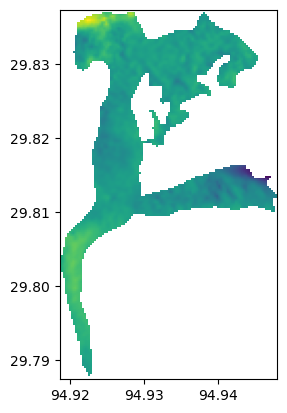

In [214]:
i_gla_1 = np.where(ele_change_ours['rgi_id']=='RGI60-13.01391')[0][0] # maps to show: 2, 8, 17; 
gla_1 = result_glaciers.iloc[i_gla_1]
masked_image_ours = np.array(gla_1['dif_map'][18])
minx, miny, maxx, maxy = gla_1.geometry.bounds
plt.imshow(masked_image_ours, extent=(minx, maxx, miny, maxy))

In [215]:
masked_image_ours[masked_image_ours==-9999] = np.nan
print(np.nanmean(masked_image_ours))


1.6201316


In [216]:
masked_image_ours[abs(masked_image_ours)>100] = np.nan
print(np.nanmean(masked_image_ours))


2.119125


Text(0.5, 1.0, 'Result by Our Method for RGI60-13.01391')

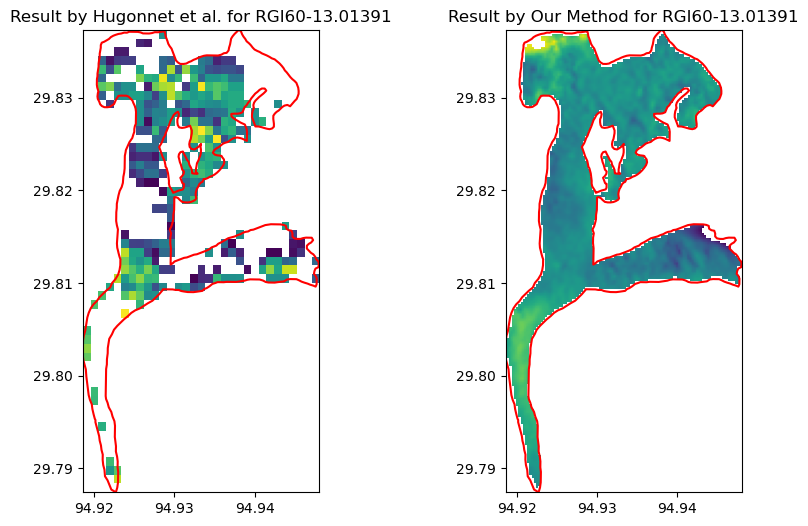

In [217]:
bounds = gla_sel_1['geometry'].bounds.values[0]
extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].imshow(masked_image[0], extent=extent)
ax[1].imshow(masked_image_ours, extent=(minx, maxx, miny, maxy))
gla_sel_1.plot(ax=ax[0], facecolor='none', edgecolor='red', linewidth=1.5)
ax[0].set_title('Result by Hugonnet et al. for RGI60-13.01391')
gla_sel_1.plot(ax=ax[1], facecolor='none', edgecolor='red', linewidth=1.5)
ax[1].set_title('Result by Our Method for RGI60-13.01391')


Glacier: RGI60-15.11833  